# Portfolio Risk Analysis

This project analyzes the risk of a stock portfolio using Python.

Objectives:
- Calculate returns and volatility
- Measure portfolio risk using VaR
- Perform stress testing

In [ ]:
!pip install yfinance

[*********************100%***********************]  5 of 5 completed


Ticker            AAPL        AMZN       GOOGL        MSFT       NVDA
Date                                                                 
2022-01-03  177.939697  170.404495  143.802994  323.160767  30.061134
2022-01-04  175.681381  167.522003  143.215836  317.619598  29.231791
2022-01-05  171.008270  164.356995  136.645615  305.426758  27.549147
2022-01-06  168.153580  163.253998  136.618332  303.013245  28.122000
2022-01-07  168.319794  162.554001  135.893845  303.167786  27.192852


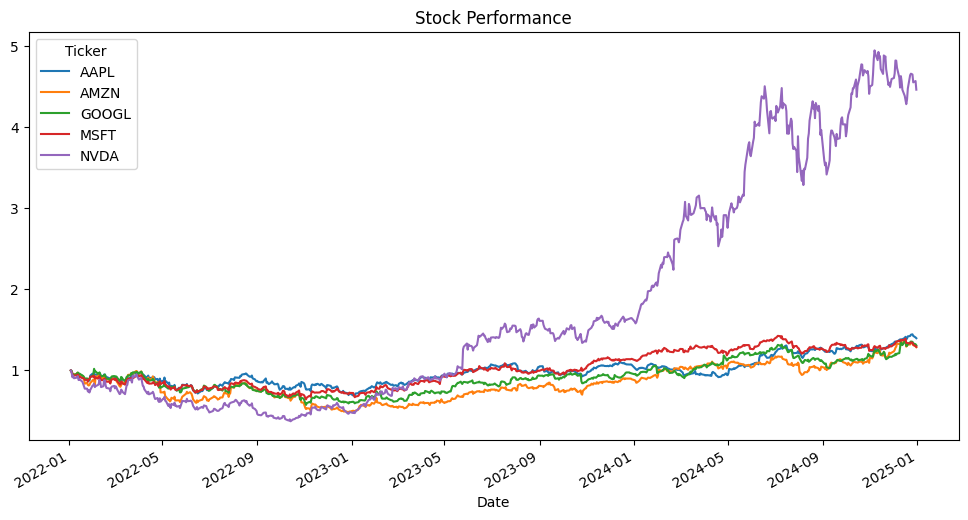

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Select stocks
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]

# Download data
data = yf.download(tickers, start="2022-01-01", end="2025-01-01", auto_adjust=True)
prices = data["Close"]

returns = prices.pct_change().dropna()

print(prices.head())

# Calculate returns
returns = prices.pct_change().dropna()

# Plot normalized prices
(prices / prices.iloc[0]).plot(figsize=(12,6))
plt.title("Stock Performance")
plt.show()

In [ ]:
# Annual return & volatility
annual_return = returns.mean() * 252
annual_vol = returns.std() * np.sqrt(252)

print("Annual Return:\n", annual_return)
print("\nAnnual Volatility:\n", annual_vol)

Annual Return:
 Ticker
AAPL     0.148965
AMZN     0.158071
GOOGL    0.144144
MSFT     0.123791
NVDA     0.652247
dtype: float64

Annual Volatility:
 Ticker
AAPL     0.270935
AMZN     0.383321
GOOGL    0.327441
MSFT     0.275766
NVDA     0.552710
dtype: float64


In [ ]:
# Equal weights
weights = np.array([1/len(tickers)] * len(tickers))

portfolio_returns = returns.dot(weights)

# VaR
var_95 = np.percentile(portfolio_returns, 5)
var_99 = np.percentile(portfolio_returns, 1)

print("95% VaR:", var_95)
print("99% VaR:", var_99)

95% VaR: -0.03053164648159467
99% VaR: -0.04851672967679689


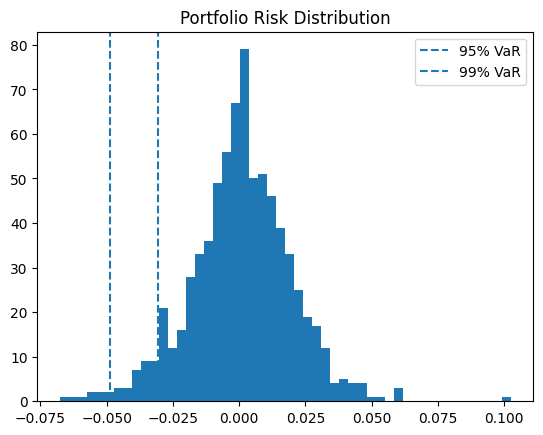

In [ ]:
plt.hist(portfolio_returns, bins=50)
plt.axvline(var_95, linestyle="--", label="95% VaR")
plt.axvline(var_99, linestyle="--", label="99% VaR")
plt.legend()
plt.title("Portfolio Risk Distribution")
plt.show()

In [ ]:
# Portfolio Value VaR in dollars
portfolio_value = 1000000

var_95_dollar = portfolio_value * var_95
print("Estimated 95% daily loss ($):", var_95_dollar)

Estimated 95% daily loss ($): -30531.64648159467


## Key Findings & Analysis

### 1. Asset Performance
Among the selected stocks, NVDA shows significantly higher annual return (~65%) compared to others (~12%–16%). However, this comes with substantially higher volatility (~55%), indicating greater uncertainty and risk.

### 2. Volatility Comparison
AMZN and GOOGL also exhibit relatively high volatility, while AAPL and MSFT are comparatively more stable. This suggests that not all assets contribute equally to portfolio risk.

### 3. Portfolio Risk (VaR)
The portfolio’s 95% Value at Risk (VaR) is approximately -3%, meaning that under normal market conditions, the portfolio could lose about 3% of its value in a single day in the worst 5% of cases. The 99% VaR (~ -4.8%) reflects more extreme downside scenarios.

### 4. Risk Concentration
Despite equal weighting, NVDA contributes disproportionately to both return and risk due to its high volatility. This highlights the importance of considering risk-adjusted contributions, not just allocation weights.

### 5. Diversification Effect
Combining multiple assets reduces overall portfolio risk compared to holding a single highly volatile stock. Diversification helps smooth returns and mitigate extreme losses.

### 6. Practical Implication
This analysis demonstrates how market risk can be quantified using historical data. Tools like volatility and VaR allow risk managers to monitor potential losses and make informed decisions on asset allocation and exposure limits.